# 03. Análise exploratória orientada à política de crédito

Este notebook vai aprofundar essa análise da base com target de inadimplência em 12 meses.

A ideia não é só gerar gráficos, mas tentar entender quais variáveis ajudam a desenhar uma política de concessão de crédito. Por isso, eu quero que cada análise tente responder uma pergunta prática:

O foco principal vai ser entender a inadimplência em 12 meses a partir de variáveis disponíveis no momento da concessão.

In [47]:
# Setup básico do notebook.
# Deixo esse bloco no começo para facilitar a reprodução no VSCode, Jupyter
# e também na exportação para HTML/PDF.

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Esse renderer força o Plotly a manter uma versão PNG do gráfico dentro
# do notebook. Isso evita que os gráficos sumam quando eu exportar o HTML
# Eu quero manter o gráfico interativo dentro do notebook, mas se ele for exportado para HTML, a versão PNG é mais confiável para garantir que o gráfico apareça.
pio.renderers.default = "notebook_connected+png"

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from concessao_credito.config import (
    PROCESSED_DIR,
    TABLES_DIR,
    FIGURES_DIR,
)

from concessao_credito.plots import (
    registrar_template_credito,
    aplicar_layout,
    salvar_figura,
)

registrar_template_credito()

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:,.4f}".format)

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Projeto:", PROJECT_ROOT)
print("Base processada:", PROCESSED_DIR)

Projeto: c:\GitHub\datascience\projetos\concessao_credito
Base processada: C:\GitHub\datascience\projetos\concessao_credito\data\processed


## 1. Leitura da base com target

Aqui eu uso a base gerada no notebook anterior, só com as operações com janela suficiente para observar inadimplência em 12 meses.

Essa aqui vai ser a base principal para EDA e, posteriormente, para modelagem.

In [48]:
# Leio a base final de modelagem com o target de inadimplência em 12 meses.

base_path = PROCESSED_DIR / "base_modelagem_12m.parquet"

base = pd.read_parquet(base_path)

# Garanto que as datas estejam no formato correto para análises temporais.
for col in ["data_concessao", "data_nascimento", "data_abertura_conta", "data_ref_12m"]:
    if col in base.columns:
        base[col] = pd.to_datetime(base[col], errors="coerce")

print("Shape da base de modelagem:", base.shape)

display(base.head())
display(base.dtypes)

Shape da base de modelagem: (19558, 30)


,id_cliente,data_concessao,valor_emprestado,valor_parcela,valor_taxa,valor_prazo,valor_renda,valor_restritivos,cat_escolaridade,flag_cliente_ativo,cod_agencia,data_nascimento,data_abertura_conta,idade_concessao,tempo_conta_anos,comprometimento_renda,restritivos_sobre_renda,id_operacao,data_ref_12m,tem_janela_12m,flag_inadimplente_12m_observado,target_inadimplente_12m,origem_target_12m,target_inadimplente_ate_12m,fx_valor_renda,fx_valor_emprestado,fx_valor_parcela,fx_comprometimento_renda,fx_valor_restritivos,fx_restritivos_sobre_renda
0,2,2020-10-02,"12,822.7800","1,119.3900",0.0358,15,"4,140.8700",5.2100,Médio Incompleto,1,89,1975-08-01,2019-12-06,45.1718,0.8241,0.2703,0.0013,2,2021-10-31,True,0.0000,0.0000,observado_no_mes_12,0.0000,"(3478.248, 5003.316]","(11630.72, 19467.92]","(1090.946, 1675.716]","(0.258, 0.416]","(4.438, 42.52]","(0.00125, 0.013]"
1,3,2020-10-01,"11,683.1500","1,540.4700",0.0357,9,"2,505.7400",0.0000,Médio Incompleto,1,61,1988-05-03,2019-10-22,32.4134,0.9446,0.6148,0.0000,3,2021-10-31,True,NaN,0.0000,sem_registro_no_mes_12_assumido_quitado,0.0000,"(1804.064, 2575.78]","(11630.72, 19467.92]","(1090.946, 1675.716]","(0.58, 0.74]","(-0.001, 4.438]","(-0.001, 0.00125]"
2,9,2020-06-05,"29,299.1400","3,143.7900",0.0412,12,"4,807.5400",15.7800,Fundamental Incompleto,0,61,1976-11-09,2018-11-23,43.5702,1.5332,0.6539,0.0033,9,2021-06-30,True,0.0000,0.0000,observado_no_mes_12,0.0000,"(3478.248, 5003.316]","(19467.92, 162511.33]","(2655.548, 23401.53]","(0.58, 0.74]","(4.438, 42.52]","(0.00125, 0.013]"
3,12,2021-04-01,"18,797.4200","2,823.7100",0.0427,8,"3,427.1200",0.0000,Sem Escolaridade,1,63,2003-04-02,2020-10-04,17.9986,0.4901,0.8239,0.0000,12,2022-04-30,True,NaN,0.0000,sem_registro_no_mes_12_assumido_quitado,0.0000,"(2575.78, 3478.248]","(11630.72, 19467.92]","(2655.548, 23401.53]","(0.74, 0.9]","(-0.001, 4.438]","(-0.001, 0.00125]"
4,15,2020-09-29,"11,975.9300","1,248.9700",0.0363,12,"1,663.7500",21.5600,Não Declarado,1,28,1985-03-25,2017-11-28,35.5154,2.8364,0.7507,0.0130,15,2021-09-30,True,0.0000,0.0000,observado_no_mes_12,0.0000,"(1199.999, 1804.064]","(11630.72, 19467.92]","(1090.946, 1675.716]","(0.74, 0.9]","(4.438, 42.52]","(0.00125, 0.013]"


id_cliente                                  int64
data_concessao                     datetime64[us]
valor_emprestado                          float64
valor_parcela                             float64
valor_taxa                                float64
valor_prazo                                 int64
valor_renda                               float64
valor_restritivos                         float64
cat_escolaridade                           string
flag_cliente_ativo                          int64
cod_agencia                                 int64
data_nascimento                    datetime64[us]
data_abertura_conta                datetime64[us]
idade_concessao                           float64
tempo_conta_anos                          float64
comprometimento_renda                     float64
restritivos_sobre_renda                   float64
id_operacao                                 int64
data_ref_12m                       datetime64[us]
tem_janela_12m                               bool


## 2. Visão geral da inadimplência em 12 meses

Antes de analisar variáveis explicativas, eu vou ver novamente o tamanho da base e a taxa geral de inadimplência.

Essa taxa vai ser a referência para interpretar todos os gráficos seguintes. Uma faixa vai ser considerada mais arriscada quando apresentar inadimplência acima da média da carteira.

In [49]:
# Defino o target principal do projeto.

target_col = "target_inadimplente_12m"

resumo_geral = pd.DataFrame({
    "indicador": [
        "qtd_operacoes",
        "qtd_inadimplentes_12m",
        "qtd_adimplentes_12m",
        "taxa_inadimplencia_12m",
    ],
    "valor": [
        len(base),
        int(base[target_col].sum()),
        int((base[target_col] == 0).sum()),
        base[target_col].mean(),
    ],
})

display(resumo_geral)

# Essa média será usada como linha de referência nos gráficos.
taxa_media_inad = base[target_col].mean()

resumo_geral.to_csv(
    TABLES_DIR / "eda_resumo_geral_target.csv",
    index=False,
    encoding="utf-8-sig",
)

,indicador,valor
0,qtd_operacoes,"19,558.0000"
1,qtd_inadimplentes_12m,"2,407.0000"
2,qtd_adimplentes_12m,"17,151.0000"
3,taxa_inadimplencia_12m,0.1231


,target_label,qtd_operacoes,pct_operacoes
0,Adimplente em 12m,17151,87.6930
1,Inadimplente em 12m,2407,12.3070


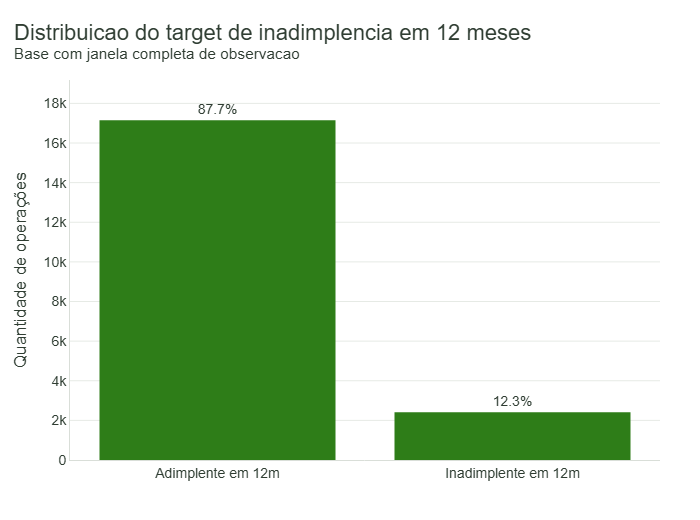

In [50]:
# Consolido a distribuição do target para verificar o desbalanceamento da base.

dist_target = (
    base
    .assign(
        target_label=np.where(
            base[target_col] == 1,
            "Inadimplente em 12m",
            "Adimplente em 12m",
        )
    )
    .groupby("target_label", as_index=False)
    .agg(qtd_operacoes=("id_operacao", "count"))
)

dist_target["pct_operacoes"] = (
    dist_target["qtd_operacoes"] / dist_target["qtd_operacoes"].sum() * 100
)

display(dist_target)

fig = px.bar(
    dist_target,
    x="target_label",
    y="qtd_operacoes",
    text="pct_operacoes",
)

fig = aplicar_layout(
    fig,
    titulo="Distribuicao do target de inadimplencia em 12 meses",
    subtitulo="Base com janela completa de observacao",
    mostrar_legenda=False,
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
)

fig.update_xaxes(title="")
fig.update_yaxes(title="Quantidade de operações")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "03_dist_target_12m.html",
)

## 3. Funções auxiliares

As funções que vou usar agora vão padronizar as análises de risco por faixa e por categoria.

Isso vai evitar repetir código e mantém as tabelas comparáveis entre variáveis diferentes.

In [51]:
def criar_faixa_quantil(df, coluna, qtd_faixas=5):
    """
    Aqui eu crio  faixas por quantis para leitura exploratória.

    eu uso quantis porque eles mantêm volumes parecidos entre as faixas.
    Isso ajuda a comparar taxa de inadimplência sem deixar grupos muito
    pequenos distorcendo a leitura.
    """
    return pd.qcut(
        df[coluna],
        q=qtd_faixas,
        duplicates="drop",
    )


def resumo_risco_por_faixa(df, coluna, qtd_faixas=5, target=target_col):
    """
    vai resumi o volume e inadimplência por faixas de uma variável numérica.

    A saída já traz a diferença em relação à taxa média da carteira,
    porque essa é a comparação que ajuda a pensar em política.
    """

    # Algumas variáveis analisadas aqui também aparecem nas colunas auxiliares
    # de resumo, como valor_renda e valor_emprestado. Por isso, monto a lista
    # sem duplicar nomes de colunas.
    colunas_necessarias = list(dict.fromkeys([
        coluna,
        target,
        "id_operacao",
        "valor_emprestado",
        "valor_renda",
    ]))

    df_aux = df[colunas_necessarias].copy()
    df_aux = df_aux[df_aux[coluna].notna()].copy()

    df_aux[f"fx_{coluna}"] = criar_faixa_quantil(
        df_aux,
        coluna,
        qtd_faixas=qtd_faixas,
    )

    # Como coluna, valor_emprestado e valor_renda podem eventualmente ser a mesma
    # variável, eu calculo os agregados principais de forma mais controlada.
    agg_dict = {
        "qtd_operacoes": ("id_operacao", "count"),
        "taxa_inadimplencia": (target, "mean"),
        "valor_min": (coluna, "min"),
        "valor_max": (coluna, "max"),
    }

    if "valor_emprestado" in df_aux.columns:
        agg_dict["valor_medio"] = ("valor_emprestado", "mean")

    if "valor_renda" in df_aux.columns:
        agg_dict["renda_media"] = ("valor_renda", "mean")

    resumo = (
        df_aux
        .groupby(f"fx_{coluna}", observed=True, as_index=False)
        .agg(**agg_dict)
    )

    resumo["taxa_inadimplencia_pct"] = resumo["taxa_inadimplencia"] * 100
    resumo["dif_vs_media_pp"] = (
        resumo["taxa_inadimplencia"] - df[target].mean()
    ) * 100

    resumo[f"fx_{coluna}"] = resumo[f"fx_{coluna}"].astype(str)

    return resumo


def resumo_risco_por_categoria(df, coluna, target=target_col, min_operacoes=50):
    """
    resume risco por variável categórica.

    uso um corte mínimo de volume para evitar conclusões baseadas em grupos
    pequenos demais. Categorias raras podem ser úteis para modelagem, mas
    são frágeis para defender uma regra de política.
    """
    resumo = (
        df
        .groupby(coluna, dropna=False, as_index=False)
        .agg(
            qtd_operacoes=("id_operacao", "count"),
            taxa_inadimplencia=(target, "mean"),
            valor_medio=("valor_emprestado", "mean"),
            renda_media=("valor_renda", "mean"),
            comprometimento_medio=("comprometimento_renda", "mean"),
        )
    )

    resumo = resumo[resumo["qtd_operacoes"] >= min_operacoes].copy()

    resumo["taxa_inadimplencia_pct"] = resumo["taxa_inadimplencia"] * 100
    resumo["dif_vs_media_pp"] = (
        resumo["taxa_inadimplencia"] - df[target].mean()
    ) * 100

    resumo = resumo.sort_values("taxa_inadimplencia", ascending=False)

    return resumo


def plotar_risco_faixa(resumo, coluna_faixa, titulo, subtitulo, nome_arquivo):
    """
    Gera gráfico de taxa de inadimplência por faixa.
    Incluo a linha da média da carteira para facilitar a leitura executiva.
    """
    fig = px.bar(
        resumo,
        x=coluna_faixa,
        y="taxa_inadimplencia_pct",
        text="taxa_inadimplencia_pct",
    )

    fig.add_hline(
        y=taxa_media_inad * 100,
        line_dash="dash",
        annotation_text="Média da carteira",
        annotation_position="top left",
    )

    fig = aplicar_layout(
        fig,
        titulo=titulo,
        subtitulo=subtitulo,
        mostrar_legenda=False,
    )

    fig.update_traces(
        texttemplate="%{text:.1f}%",
        textposition="outside",
    )

    fig.update_xaxes(title="")
    fig.update_yaxes(title="Taxa de inadimplência em 12m", ticksuffix="%")

    fig.show()

    salvar_figura(
        fig,
        caminho_html=FIGURES_DIR / nome_arquivo,
    )

    return fig

## 4. Inadimplência por safra de concessão

A primeira leitura é temporal. Eu quero entender se a taxa de inadimplência muda muito entre os meses de concessão.

Se houver variação relevante ao longo do tempo, isso vai reforçar a necessidade de validação temporal na modelagem, em vez de uma separação aleatória simples.

In [52]:
# Eu crio uma variável de safra mensal para acompanhar o risco por mês de concessão.
# Essa leitura é importante porque modelos de crédito costumam sofrer variação temporal:
# mudanças de política, cenário econômico ou perfil dos clientes podem alterar a inadimplência.

risco_safra = (
    base
    .assign(
        mes_concessao=base["data_concessao"].dt.to_period("M").astype(str)
    )
    .groupby("mes_concessao", as_index=False)
    .agg(
        qtd_operacoes=("id_operacao", "count"),
        taxa_inadimplencia=(target_col, "mean"),
        valor_medio=("valor_emprestado", "mean"),
        renda_media=("valor_renda", "mean"),
        comprometimento_medio=("comprometimento_renda", "mean"),
    )
)

# Transformo a taxa para percentual para facilitar leitura no notebook,
# relatório e apresentação.
risco_safra["taxa_inadimplencia_pct"] = (
    risco_safra["taxa_inadimplencia"] * 100
)

display(risco_safra)

# Salvo a tabela porque ela pode ser usada depois para justificar
# a estratégia de validação temporal do modelo.
risco_safra.to_csv(
    TABLES_DIR / "eda_risco_por_safra.csv",
    index=False,
    encoding="utf-8-sig",
)

,mes_concessao,qtd_operacoes,taxa_inadimplencia,valor_medio,renda_media,comprometimento_medio,taxa_inadimplencia_pct
0,2019-08,364,0.1401,"13,581.7971","3,567.2113",0.5069,14.0110
1,2019-09,821,0.1181,"13,323.3995","3,697.4336",0.5060,11.8149
2,2019-10,863,0.1321,"13,815.8615","3,703.4101",0.5063,13.2097
3,2019-11,816,0.1201,"12,106.7246","3,371.9274",0.4968,12.0098
4,2019-12,829,0.1279,"12,596.0910","3,539.6184",0.4883,12.7865
5,2020-01,917,0.1200,"13,231.1917","3,648.1836",0.5085,11.9956
6,2020-02,756,0.1124,"13,743.5937","3,737.2265",0.4915,11.2434
7,2020-03,890,0.1157,"12,824.0887","3,564.3128",0.4888,11.5730
8,2020-04,756,0.1257,"13,310.9340","3,649.0074",0.5118,12.5661
9,2020-05,870,0.1126,"13,098.2017","3,539.8112",0.5057,11.2644


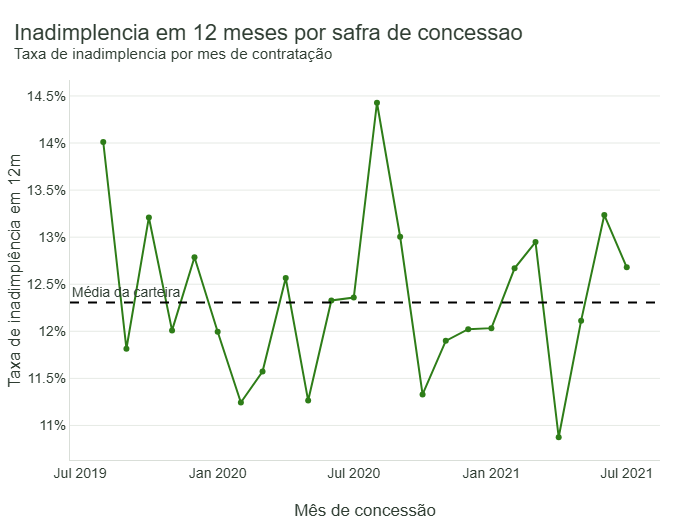

In [53]:
# Gráfico temporal da inadimplência por safra.
# A linha tracejada mostra a média geral da carteira, servindo como referência
# para identificar meses acima ou abaixo do risco médio.

fig = px.line(
    risco_safra,
    x="mes_concessao",
    y="taxa_inadimplencia_pct",
    markers=True,
)

fig.add_hline(
    y=taxa_media_inad * 100,
    line_dash="dash",
    annotation_text="Média da carteira",
    annotation_position="top left",
)

fig = aplicar_layout(
    fig,
    titulo="Inadimplencia em 12 meses por safra de concessao",
    subtitulo="Taxa de inadimplencia por mes de contratação",
    mostrar_legenda=False,
)

fig.update_xaxes(title="Mês de concessão")
fig.update_yaxes(title="Taxa de inadimplência em 12m", ticksuffix="%")

fig.show()

# Salvo uma versão HTML para consulta posterior.
# O PNG fica preservado no notebook por causa do renderer definido no setup.
salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "03_risco_por_safra.html",
)

## 5. Renda mensal

A renda é uma variável importante, mas não deve ser analisada sozinha.

A renda vai me ajudar a estimar a capacidade de pagamento, mas o risco real depende também da parcela, do prazo, da taxa e de outras dívidas do cliente.

,fx_valor_renda,qtd_operacoes,taxa_inadimplencia,valor_min,valor_max,valor_medio,renda_media,taxa_inadimplencia_pct,dif_vs_media_pp
0,"(1199.999, 1804.064]",3912,0.1299,"1,200.0000","1,804.0400","5,102.3644","1,420.6610",12.9857,0.6787
1,"(1804.064, 2575.78]",3911,0.1319,"1,804.1000","2,575.6600","7,955.8264","2,185.0078",13.1936,0.8866
2,"(2575.78, 3478.248]",3912,0.1191,"2,575.8100","3,478.2000","10,869.2819","2,999.7959",11.9121,-0.3949
3,"(3478.248, 5003.316]",3911,0.1243,"3,478.4400","5,003.2500","15,052.7638","4,158.4164",12.4265,0.1195
4,"(5003.316, 30758.56]",3912,0.1102,"5,003.3600","30,758.5600","26,644.2779","7,318.7621",11.0174,-1.2896


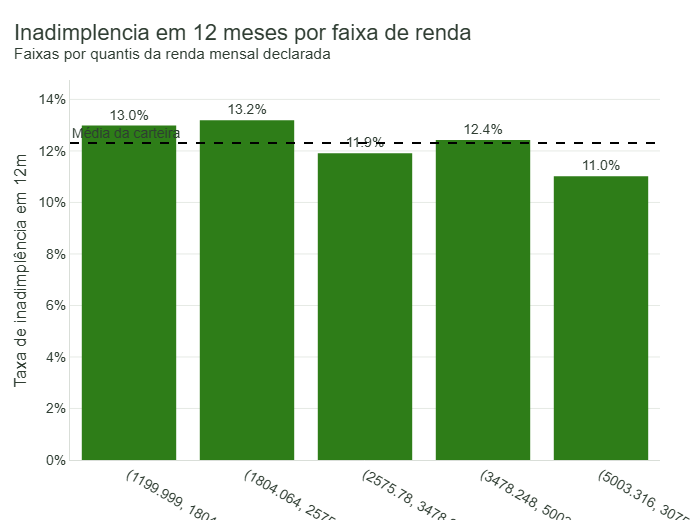

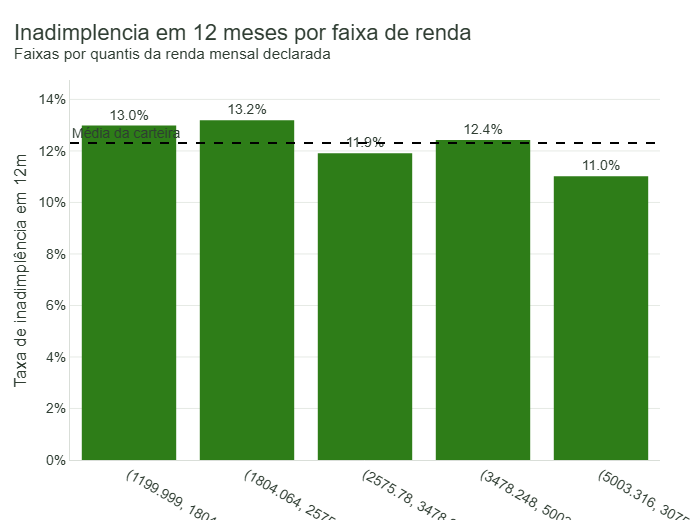

In [54]:
# Aqui eu divido a renda em faixas para verificar se ela separa bons e maus pagadores.
# A renda é importante para capacidade de pagamento, mas é melhor não usar ela sozinho,
# porque o risco também depende de parcela, restritivos e valor solicitado.

risco_renda = resumo_risco_por_faixa(
    base,
    coluna="valor_renda",
    qtd_faixas=5,
)

display(risco_renda)

# Salvo a tabela para reutilizar os números nas conclusões e no relatório.
risco_renda.to_csv(
    TABLES_DIR / "eda_risco_por_renda.csv",
    index=False,
    encoding="utf-8-sig",
)

# Comparo cada faixa de renda contra a média da carteira.
# Se a renda não apresentar separação clara, isso revai refoarçar a necessidade
# de usar variáveis de comprometimento e restritivos na política.
plotar_risco_faixa(
    risco_renda,
    coluna_faixa="fx_valor_renda",
    titulo="Inadimplencia em 12 meses por faixa de renda",
    subtitulo="Faixas por quantis da renda mensal declarada",
    nome_arquivo="03_risco_por_renda.html",
)

## 6. Valor emprestado

aqui eu avalio se operações de maior valor apresentam maior inadimplência.

essa leitura é importante porque a política precisa definir não apenas quem ela vai aprovar, mas também qual valor máximo ela vai conceder. Se o risco cresce muito nas faixas superiores, o limite máximo tem que ser condicionado ao score e à capacidade de pagamento.

,fx_valor_emprestado,qtd_operacoes,taxa_inadimplencia,valor_min,valor_max,valor_medio,renda_media,taxa_inadimplencia_pct,dif_vs_media_pp
0,"(344.97900000000004, 4085.724]",3912,0.0723,344.9800,"4,085.5000","2,612.5112","2,159.1396",7.2342,-5.0728
1,"(4085.724, 7249.594]",3911,0.1102,"4,086.0600","7,249.2900","5,611.8335","2,779.4309",11.0202,-1.2868
2,"(7249.594, 11630.72]",3912,0.1408,"7,249.6700","11,630.2800","9,254.1970","3,179.3691",14.0849,1.7779
3,"(11630.72, 19467.92]",3911,0.1442,"11,632.4800","19,460.3300","15,064.8149","3,916.6027",14.4209,2.1139
4,"(19467.92, 162511.33]",3912,0.1478,"19,472.9800","162,511.3300","33,080.5616","6,048.1911",14.7751,2.4681


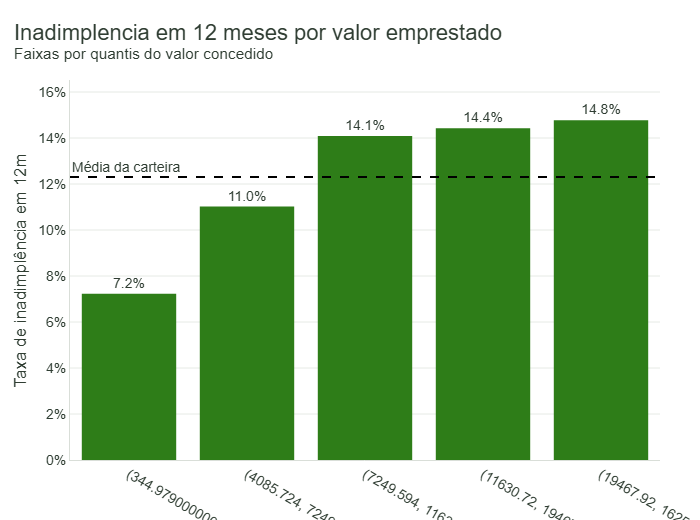

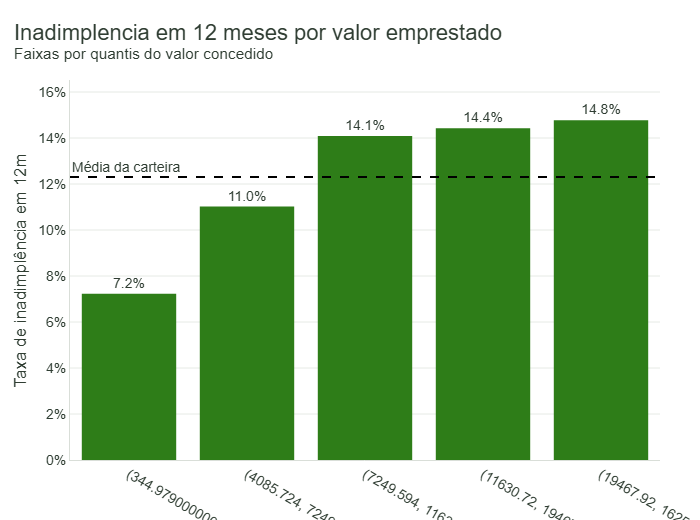

In [55]:
# Aqui eu analiso o valor emprestado porque a política precisa definir limite máximo.
# eu quero entender se operações maiores concentram maior risco de inadimplência.

risco_valor_emprestado = resumo_risco_por_faixa(
    base,
    coluna="valor_emprestado",
    qtd_faixas=5,
)

display(risco_valor_emprestado)

# Esta tabela vai me ajudar a conectar risco com exposição financeira.
risco_valor_emprestado.to_csv(
    TABLES_DIR / "eda_risco_por_valor_emprestado.csv",
    index=False,
    encoding="utf-8-sig",
)

# Se essa taxa de inadimplência crescer nas maiores faixas,
# a política final deve limitar valor concedido por faixa de risco.
plotar_risco_faixa(
    risco_valor_emprestado,
    coluna_faixa="fx_valor_emprestado",
    titulo="Inadimplencia em 12 meses por valor emprestado",
    subtitulo="Faixas por quantis do valor concedido",
    nome_arquivo="03_risco_por_valor_emprestado.html",
)

## 7. Valor da parcela

O valor da parcela é uma ponte entre o valor contratado e a capacidade real de pagamento do cliente.

Mesmo que dois clientes tenham o mesmo valor emprestado, o risco pode ser diferente se a parcela mensal representar pesos muito distintos no orçamento.

,fx_valor_parcela,qtd_operacoes,taxa_inadimplencia,valor_min,valor_max,valor_medio,renda_media,taxa_inadimplencia_pct,dif_vs_media_pp
0,"(120.539, 671.348]",3912,0.0575,120.5400,671.2800,"3,210.1496","2,108.2166",5.7515,-6.5555
1,"(671.348, 1090.946]",3911,0.1217,671.4500,"1,090.9300","6,358.1559","2,547.3546",12.1708,-0.1362
2,"(1090.946, 1675.716]",3912,0.1350,"1,090.9500","1,675.6500","9,898.9626","3,073.3274",13.4969,1.1899
3,"(1675.716, 2655.548]",3911,0.1544,"1,675.9800","2,655.5000","15,446.7257","3,918.7995",15.4436,3.1366
4,"(2655.548, 23401.53]",3912,0.1467,"2,655.5800","23,401.5300","30,710.2130","6,434.9766",14.6728,2.3658


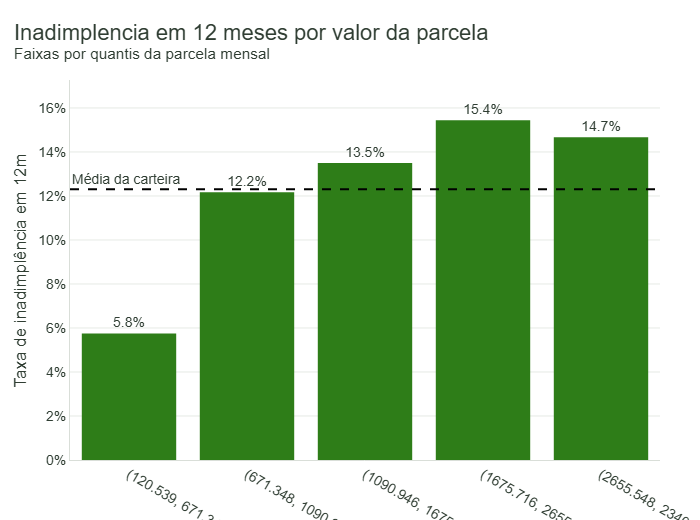

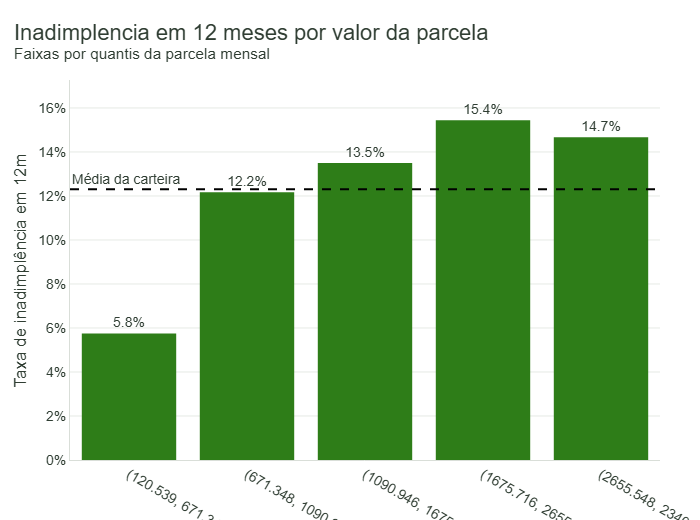

In [56]:
# Agora eu o valor da parcela porque ele representa o esforço mensal do cliente.
# Essa variável é mais próxima da capacidade de pagamento do que o valor total emprestado.

risco_parcela = resumo_risco_por_faixa(
    base,
    coluna="valor_parcela",
    qtd_faixas=5,
)

display(risco_parcela)

risco_parcela.to_csv(
    TABLES_DIR / "eda_risco_por_valor_parcela.csv",
    index=False,
    encoding="utf-8-sig",
)

# O gráfico me ajuda a verificar se parcelas maiores estão associadas
# a maior inadimplência em 12 meses.
plotar_risco_faixa(
    risco_parcela,
    coluna_faixa="fx_valor_parcela",
    titulo="Inadimplencia em 12 meses por valor da parcela",
    subtitulo="Faixas por quantis da parcela mensal",
    nome_arquivo="03_risco_por_valor_parcela.html",
)

## 8. Comprometimento de renda

Esta é uma das variáveis mais importantes para a política.

O comprometimento de renda mede quanto da renda mensal fica tomada pela parcela do empréstimo. Na prática, essa variável ajuda a transformar o modelo de risco em uma regra de valor máximo concedido.

,fx_comprometimento_renda,qtd_operacoes,taxa_inadimplencia,valor_min,valor_max,valor_medio,renda_media,taxa_inadimplencia_pct,dif_vs_media_pp
0,"(0.099, 0.258]",3912,0.0171,0.1002,0.2575,"4,659.2140","3,601.5892",1.7127,-10.5943
1,"(0.258, 0.416]",3911,0.1304,0.2577,0.4163,"8,772.7817","3,615.5706",13.0401,0.7332
2,"(0.416, 0.58]",3912,0.1501,0.4164,0.5804,"12,778.0220","3,550.7912",15.0051,2.6981
3,"(0.58, 0.74]",3911,0.1631,0.5805,0.7399,"17,435.9392","3,629.4777",16.3130,4.0060
4,"(0.74, 0.9]",3912,0.1547,0.7399,0.8999,"21,979.3755","3,685.4449",15.4652,3.1583


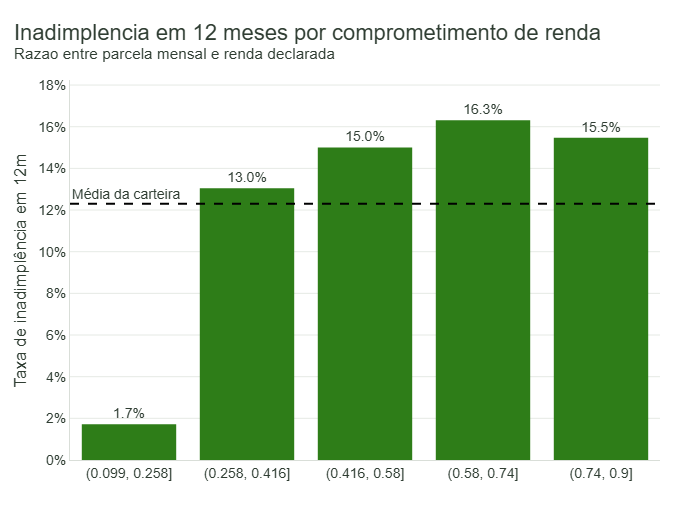

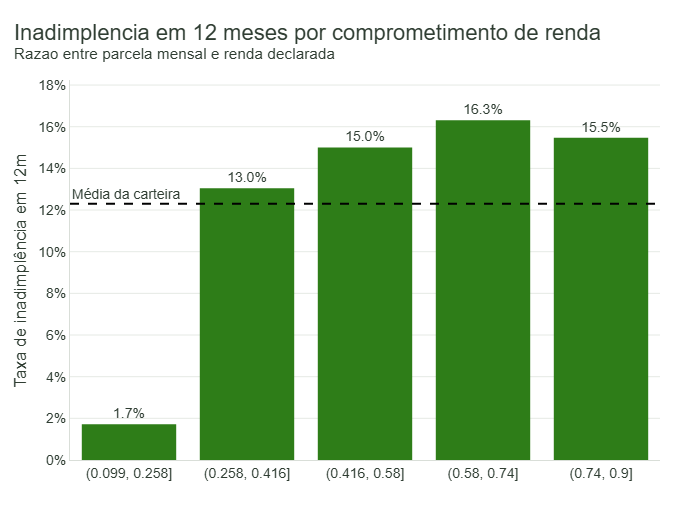

In [57]:
# O comprometimento de renda mede a relação entre parcela e renda.

risco_comprometimento = resumo_risco_por_faixa(
    base,
    coluna="comprometimento_renda",
    qtd_faixas=5,
)

display(risco_comprometimento)

risco_comprometimento.to_csv(
    TABLES_DIR / "eda_risco_por_comprometimento_renda.csv",
    index=False,
    encoding="utf-8-sig",
)

# Se as faixas de maior comprometimento tiverem inadimplência maior,
# isso justifica limitar a parcela máxima em relação à renda.
plotar_risco_faixa(
    risco_comprometimento,
    coluna_faixa="fx_comprometimento_renda",
    titulo="Inadimplencia em 12 meses por comprometimento de renda",
    subtitulo="Razao entre parcela mensal e renda declarada",
    nome_arquivo="03_risco_por_comprometimento_renda.html",
)

## 9. Valor de restritivos

O valor de restritivos representa dívidas cadastradas em órgãos de proteção ao crédito.

Essa variável deve ter papel importante na política porque sinaliza pressão financeira anterior à concessão. Além do valor absoluto, também analiso a proporção dos restritivos frente à renda.

,fx_valor_restritivos,qtd_operacoes,taxa_inadimplencia,valor_min,valor_max,valor_medio,renda_media,taxa_inadimplencia_pct,dif_vs_media_pp
0,"(-0.001, 4.438]",7823,0.0699,0.0000,4.4300,"13,072.5857","3,592.3656",6.9922,-5.3148
1,"(4.438, 42.52]",3913,0.0756,4.4400,42.5200,"13,105.5701","3,625.4345",7.5645,-4.7425
2,"(42.52, 103.558]",3910,0.1818,42.5300,103.5400,"13,204.8858","3,588.9948",18.1841,5.8772
3,"(103.558, 1231.35]",3912,0.2180,103.5700,"1,231.3500","13,169.7480","3,683.6875",21.8047,9.4977


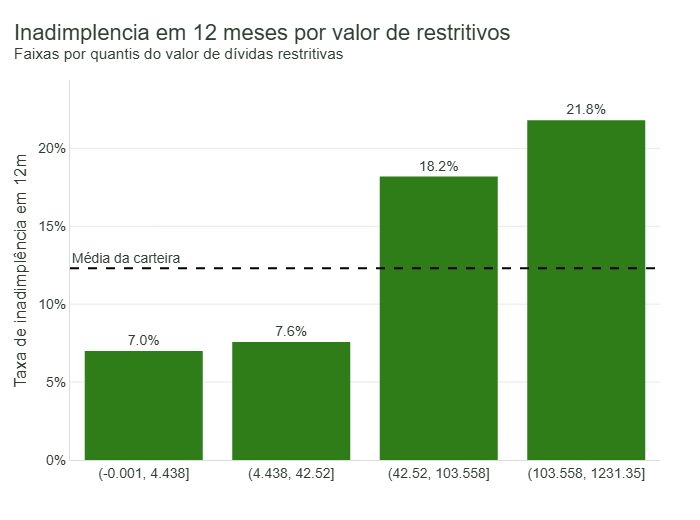

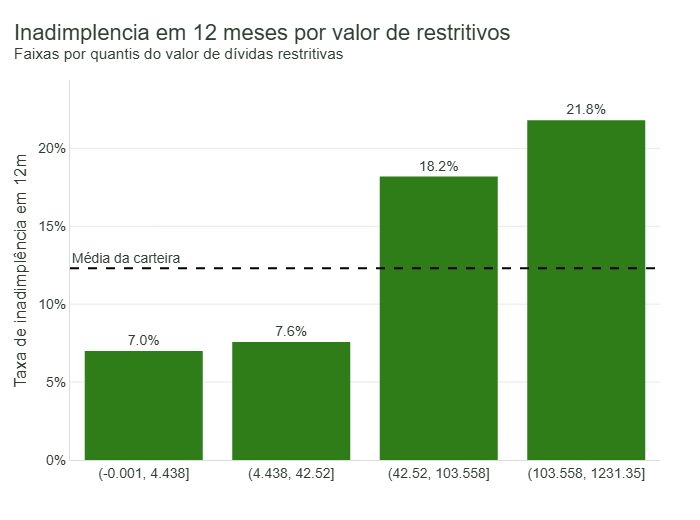

In [58]:
# aqui eu analiso o valor de restritivos como sinal de endividamento ou pressão financeira prévia.
# essa variável pode ser usada depois como critério de recusa, revisão manual
# ou redutor de limite.

risco_restritivos = resumo_risco_por_faixa(
    base,
    coluna="valor_restritivos",
    qtd_faixas=5,
)

display(risco_restritivos)

risco_restritivos.to_csv(
    TABLES_DIR / "eda_risco_por_valor_restritivos.csv",
    index=False,
    encoding="utf-8-sig",
)

# aqui eu comparo faixas de restritivos contra a média da carteira.
# a expectativa é que clientes com maiores restritivos tenham maior risco.
plotar_risco_faixa(
    risco_restritivos,
    coluna_faixa="fx_valor_restritivos",
    titulo="Inadimplencia em 12 meses por valor de restritivos",
    subtitulo="Faixas por quantis do valor de dívidas restritivas",
    nome_arquivo="03_risco_por_valor_restritivos.html",
)

,fx_restritivos_sobre_renda,qtd_operacoes,taxa_inadimplencia,valor_min,valor_max,valor_medio,renda_media,taxa_inadimplencia_pct,dif_vs_media_pp
0,"(-0.001, 0.00125]",7823,0.0695,0.0000,0.0012,"13,494.3306","3,696.1592",6.9539,-5.3531
1,"(0.00125, 0.013]",3912,0.0913,0.0012,0.0130,"16,588.8146","4,583.5435",9.1258,-3.1812
2,"(0.013, 0.0353]",3911,0.1680,0.0130,0.0353,"13,106.3416","3,620.0990",16.7988,4.4918
3,"(0.0353, 0.522]",3912,0.2170,0.0353,0.5220,"8,941.6151","2,486.9310",21.7025,9.3955


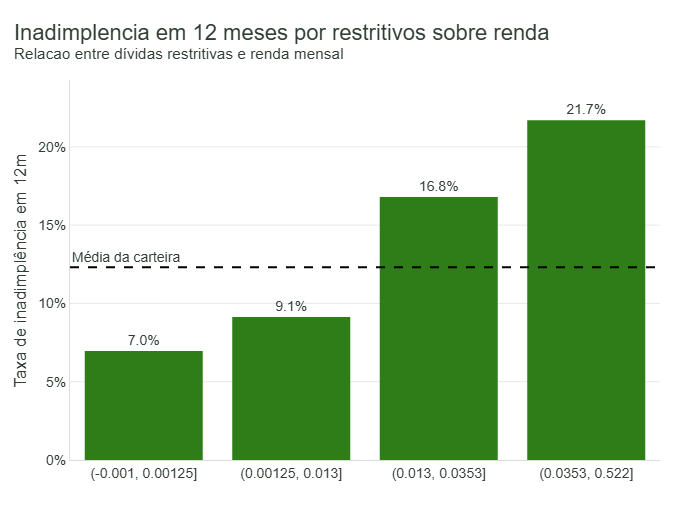

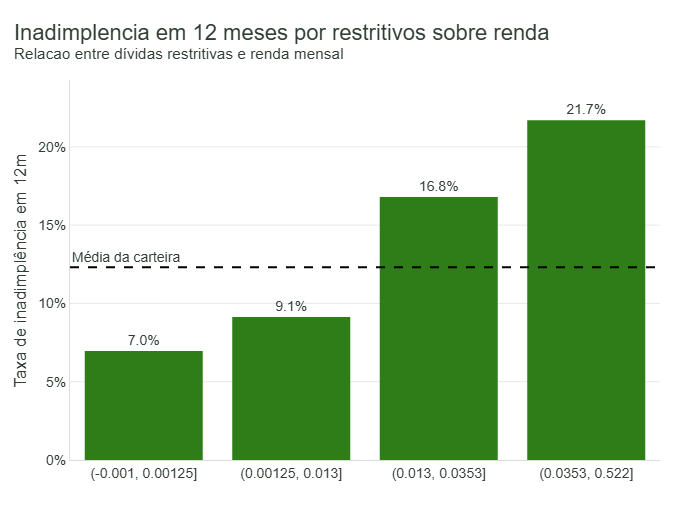

In [59]:
# Agora eu relativizo os restritivos pela renda.
# isso aqui vai ser importante porque o mesmo valor de dívida pesa de forma diferente
# para clientes com rendas distintas.

risco_restritivos_renda = resumo_risco_por_faixa(
    base,
    coluna="restritivos_sobre_renda",
    qtd_faixas=5,
)

display(risco_restritivos_renda)

risco_restritivos_renda.to_csv(
    TABLES_DIR / "eda_risco_por_restritivos_sobre_renda.csv",
    index=False,
    encoding="utf-8-sig",
)

# essa visão tende a ser mais útil para política do que o valor absoluto,
# pois considera a capacidade financeira do cliente.
plotar_risco_faixa(
    risco_restritivos_renda,
    coluna_faixa="fx_restritivos_sobre_renda",
    titulo="Inadimplencia em 12 meses por restritivos sobre renda",
    subtitulo="Relacao entre dívidas restritivas e renda mensal",
    nome_arquivo="03_risco_por_restritivos_sobre_renda.html",
)

## 10. Prazo e taxa da operação

Prazo e taxa são variáveis da operação, não só do cliente.

elas precisam ser analisadas com cuidado porque podem refletir tanto risco quanto decisão comercial anterior. Mesmo assim, são importantes para a política, já que afetam diretamente o valor da parcela e o custo total do crédito.

,fx_valor_prazo,qtd_operacoes,taxa_inadimplencia,valor_min,valor_max,valor_medio,renda_media,taxa_inadimplencia_pct,dif_vs_media_pp
0,"(2.999, 5.0]",4521,0.1161,3,5,"6,480.9961","3,576.8749",11.6125,-0.6945
1,"(5.0, 8.0]",4434,0.1267,6,8,"11,159.0924","3,727.4043",12.6748,0.3678
2,"(8.0, 10.0]",3090,0.1285,9,10,"14,078.7715","3,603.8044",12.8479,0.5409
3,"(10.0, 13.0]",4508,0.1304,11,13,"16,773.6337","3,567.0741",13.0435,0.7365
4,"(13.0, 15.0]",3005,0.1115,14,15,"19,567.7698","3,600.1561",11.1481,-1.1589


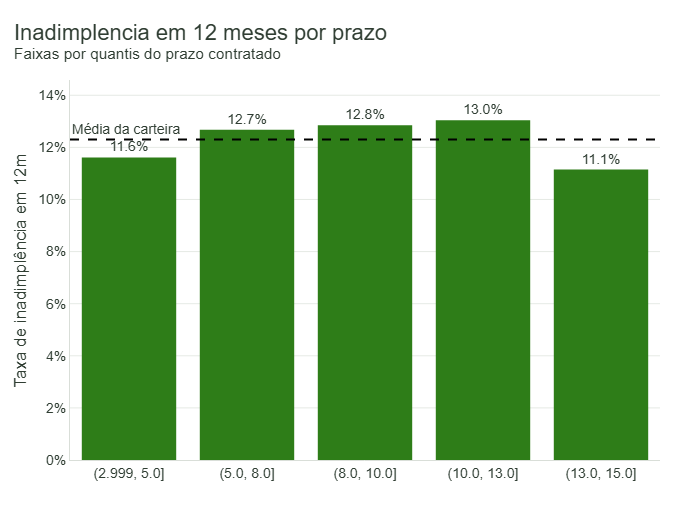

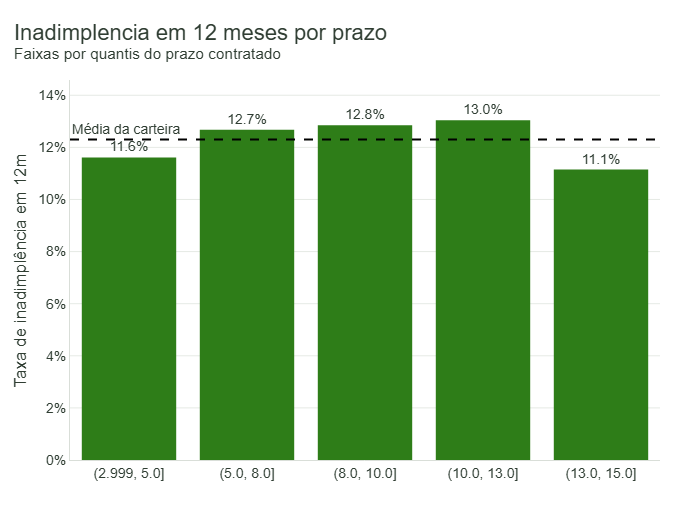

In [60]:
# eu analiso o prazo porque ele altera o tempo de exposição ao risco.
# operações mais longas podem ter parcelas menores, mas deixam o banco exposto
# por mais tempo.

risco_prazo = resumo_risco_por_faixa(
    base,
    coluna="valor_prazo",
    qtd_faixas=5,
)

display(risco_prazo)

risco_prazo.to_csv(
    TABLES_DIR / "eda_risco_por_prazo.csv",
    index=False,
    encoding="utf-8-sig",
)

# aqui eu comparo a inadimplência por faixas de prazo para avaliar se operações longas
# precisam de controle específico na política.
plotar_risco_faixa(
    risco_prazo,
    coluna_faixa="fx_valor_prazo",
    titulo="Inadimplencia em 12 meses por prazo",
    subtitulo="Faixas por quantis do prazo contratado",
    nome_arquivo="03_risco_por_prazo.html",
)

,fx_valor_taxa,qtd_operacoes,taxa_inadimplencia,valor_min,valor_max,valor_medio,renda_media,taxa_inadimplencia_pct,dif_vs_media_pp
0,"(0.0192, 0.0357]",3912,0.1258,0.0202,0.0357,"13,477.1267","3,581.8060",12.5767,0.2697
1,"(0.0357, 0.0387]",3911,0.1332,0.0357,0.0387,"13,661.7688","3,652.0249",13.3214,1.0144
2,"(0.0387, 0.0412]",3912,0.1166,0.0387,0.0412,"12,965.7932","3,614.5853",11.6564,-0.6505
3,"(0.0412, 0.0441]",3911,0.1199,0.0412,0.0441,"12,827.5891","3,599.3409",11.9918,-0.3152
4,"(0.0441, 0.0579]",3912,0.1199,0.0441,0.0579,"12,693.1263","3,635.1182",11.9888,-0.3182


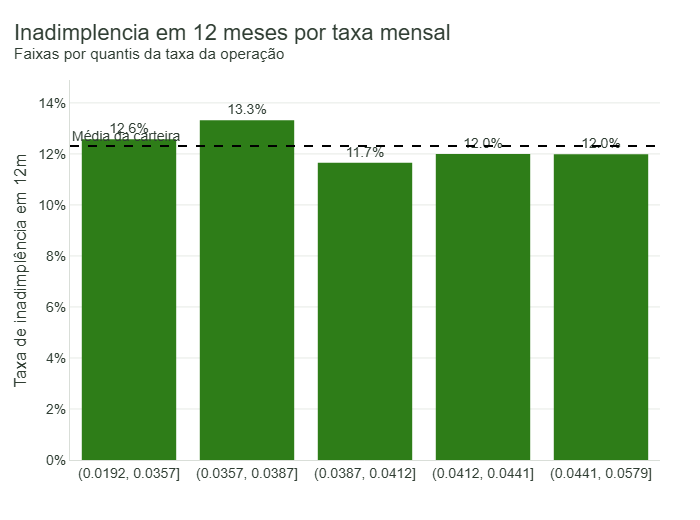

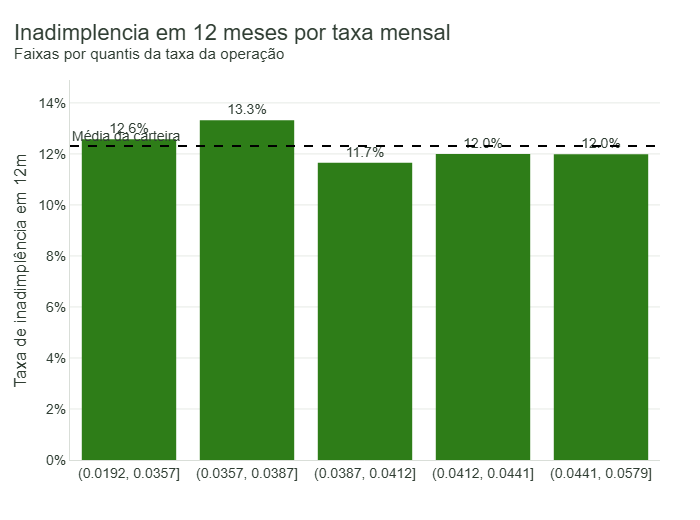

In [61]:
# aqui eu analiso a taxa mensal da operação.
# a taxa pode refletir tanto uma condição comercial quanto uma precificação prévia de risco.

risco_taxa = resumo_risco_por_faixa(
    base,
    coluna="valor_taxa",
    qtd_faixas=5,
)

display(risco_taxa)

risco_taxa.to_csv(
    TABLES_DIR / "eda_risco_por_taxa.csv",
    index=False,
    encoding="utf-8-sig",
)

# Se essas taxas maiores estiverem associadas a maior inadimplência,
# isso pode indicar que o histórico já precificava parte do risco.
plotar_risco_faixa(
    risco_taxa,
    coluna_faixa="fx_valor_taxa",
    titulo="Inadimplencia em 12 meses por taxa mensal",
    subtitulo="Faixas por quantis da taxa da operação",
    nome_arquivo="03_risco_por_taxa.html",
)

## 11. Idade e tempo de conta

Agora eu vou analisar as variáveis de perfil e relacionamento.

Idade e tempo de conta podem capturar maturidade financeira, estabilidade cadastral e histórico de relacionamento com a instituição. Para política, essas variáveis tendem a funcionar melhor como ajuste de risco do que como regra isolada.

,fx_idade_concessao,qtd_operacoes,taxa_inadimplencia,valor_min,valor_max,valor_medio,renda_media,taxa_inadimplencia_pct,dif_vs_media_pp
0,"(17.997999999999998, 26.694]",3913,0.1779,17.9986,26.6940,"13,010.8177","3,580.2209",17.7869,5.4799
1,"(26.694, 32.487]",3910,0.1317,26.6968,32.4846,"13,117.5308","3,652.0217",13.1714,0.8644
2,"(32.487, 37.604]",3914,0.1196,32.4873,37.6044,"13,473.4291","3,623.9263",11.9571,-0.3499
3,"(37.604, 43.469]",3909,0.1003,37.6099,43.4661,"13,071.2063","3,639.9636",10.0281,-2.2788
4,"(43.469, 73.676]",3912,0.0859,43.4716,73.6756,"12,952.1650","3,586.7796",8.5890,-3.7180


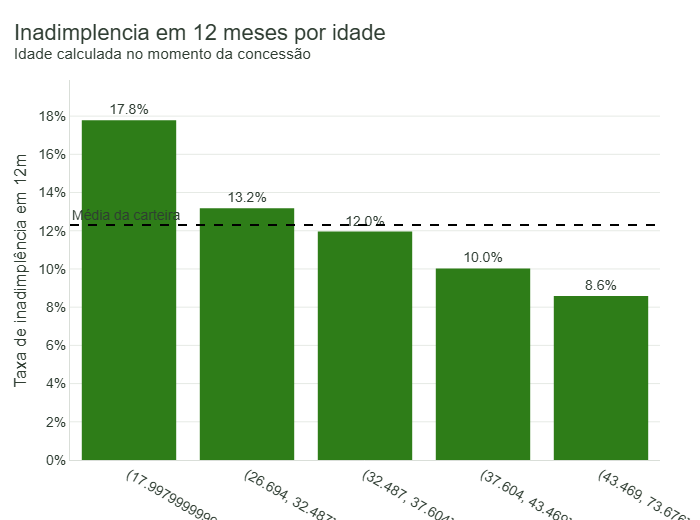

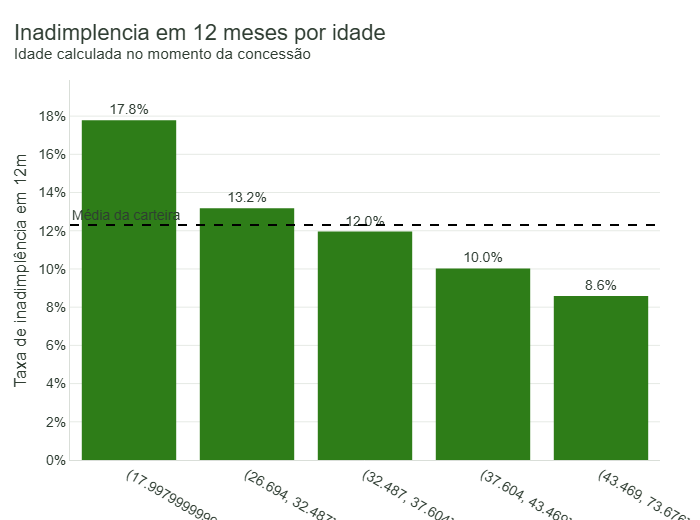

In [62]:
# Eu analiso a idade como variável cadastral de perfil.
# Ela pode capturar diferenças de maturidade financeira, mas tem que ser usada com cautela
# e sempre combinada com variáveis financeiras.

risco_idade = resumo_risco_por_faixa(
    base,
    coluna="idade_concessao",
    qtd_faixas=5,
)

display(risco_idade)

risco_idade.to_csv(
    TABLES_DIR / "eda_risco_por_idade.csv",
    index=False,
    encoding="utf-8-sig",
)

plotar_risco_faixa(
    risco_idade,
    coluna_faixa="fx_idade_concessao",
    titulo="Inadimplencia em 12 meses por idade",
    subtitulo="Idade calculada no momento da concessão",
    nome_arquivo="03_risco_por_idade.html",
)

,fx_tempo_conta_anos,qtd_operacoes,taxa_inadimplencia,valor_min,valor_max,valor_medio,renda_media,taxa_inadimplencia_pct,dif_vs_media_pp
0,"(0.221, 1.095]",3932,0.1938,0.2218,1.0951,"12,795.2333","3,556.7618",19.3795,7.0725
1,"(1.095, 1.47]",3904,0.1432,1.0979,1.4702,"13,126.9727","3,597.2220",14.3186,2.0117
2,"(1.47, 1.884]",3910,0.1151,1.4730,1.8836,"13,648.7645","3,674.4556",11.5090,-0.7980
3,"(1.884, 2.549]",3905,0.0927,1.8864,2.5489,"13,000.0963","3,630.1710",9.2702,-3.0368
4,"(2.549, 11.075]",3907,0.0701,2.5517,11.0746,"13,055.9221","3,624.5906",7.0131,-5.2939


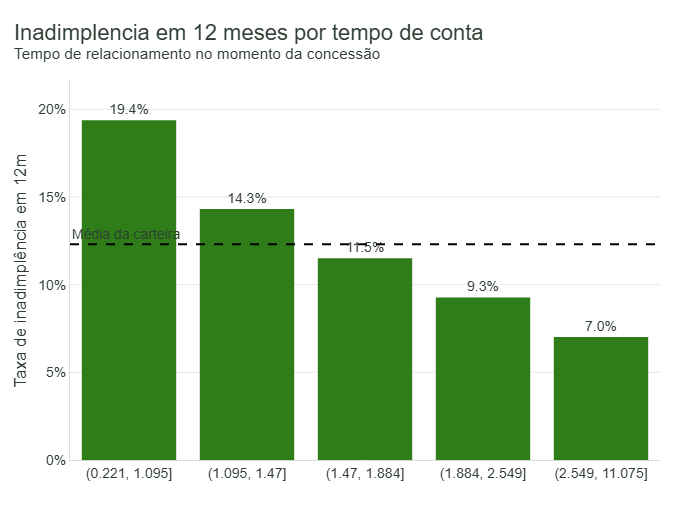

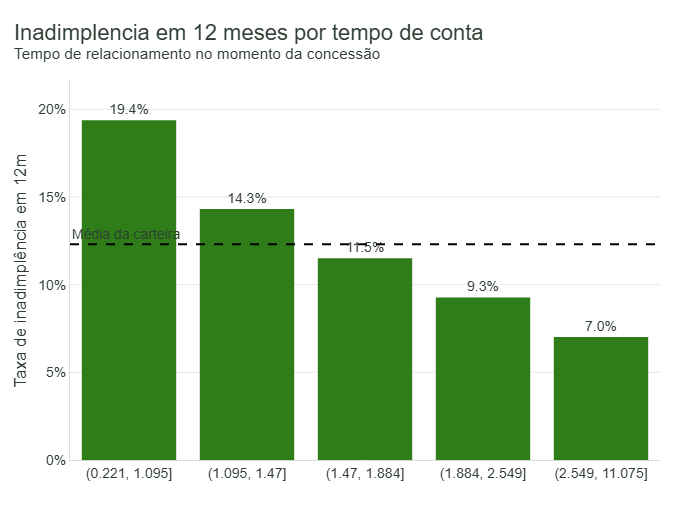

In [63]:
# Eu analiso tempo de conta como proxy de relacionamento com a instituição.
# clientes com mais histórico podem ter comportamento diferente de clientes recentes.

risco_tempo_conta = resumo_risco_por_faixa(
    base,
    coluna="tempo_conta_anos",
    qtd_faixas=5,
)

display(risco_tempo_conta)

risco_tempo_conta.to_csv(
    TABLES_DIR / "eda_risco_por_tempo_conta.csv",
    index=False,
    encoding="utf-8-sig",
)

plotar_risco_faixa(
    risco_tempo_conta,
    coluna_faixa="fx_tempo_conta_anos",
    titulo="Inadimplencia em 12 meses por tempo de conta",
    subtitulo="Tempo de relacionamento no momento da concessão",
    nome_arquivo="03_risco_por_tempo_conta.html",
)

## 12. Escolaridade

A escolaridade é uma variável cadastral e tem que ser usada com cautela.

Aqui eu vou observar se tem diferença relevante de risco entre grupos, mas a decisão de política não deve depender exclusivamente de uma variável desse tipo.

In [64]:
# Agora eu analiso escolaridade como variável cadastral.
# Ela deve ajudar o modelo, mas não deve virar regra isolada de concessão.

risco_escolaridade = resumo_risco_por_categoria(
    base,
    coluna="cat_escolaridade",
    min_operacoes=50,
)

display(risco_escolaridade)

risco_escolaridade.to_csv(
    TABLES_DIR / "eda_risco_por_escolaridade.csv",
    index=False,
    encoding="utf-8-sig",
)

,cat_escolaridade,qtd_operacoes,taxa_inadimplencia,valor_medio,renda_media,comprometimento_medio,taxa_inadimplencia_pct,dif_vs_media_pp
4,Não Declarado,3198,0.2830,"12,848.1975","3,557.9931",0.4977,28.2989,15.9920
5,Não informado,267,0.2584,"13,327.8609","3,768.6529",0.4831,25.8427,13.5357
7,Sem Escolaridade,2941,0.2132,"13,152.7444","3,615.9421",0.5019,21.3193,9.0123
2,Médio Completo,1509,0.0716,"12,752.0614","3,566.0235",0.4922,7.1571,-5.1499
1,Fundamental Incompleto,5146,0.0653,"13,290.2419","3,646.0453",0.4991,6.5293,-5.7776
3,Médio Incompleto,1721,0.0645,"13,374.8470","3,677.9677",0.4971,6.4497,-5.8572
8,Superior Completo,916,0.0600,"14,097.2286","3,655.5777",0.5159,6.0044,-6.3026
0,Fundamental Completo,2022,0.0579,"12,898.0392","3,612.0004",0.4904,5.7864,-6.5206
9,Superior Incompleto,1202,0.0549,"13,113.3543","3,589.3695",0.5073,5.4908,-6.8161
6,Pós-graduação,636,0.0204,"12,520.5816","3,575.3488",0.4969,2.0440,-10.2630


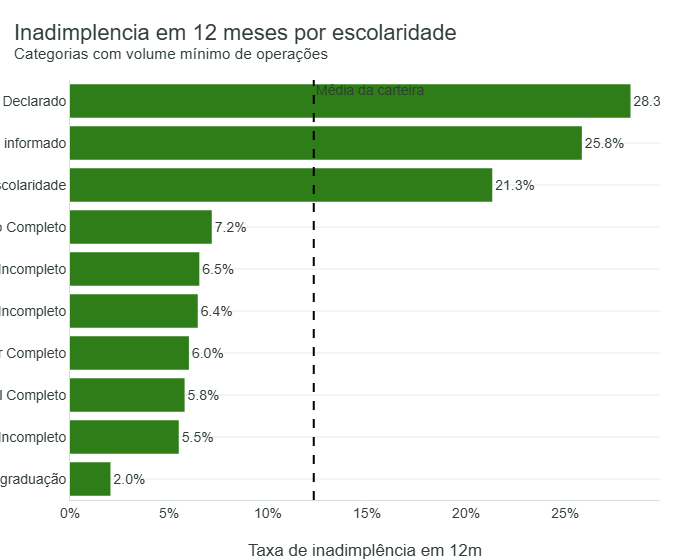

In [65]:
# aqui eu vou usar gráfico horizontal porque categorias textuais ficam mais legíveis nesse formato.
# a linha vertical mostra a média da carteira como referência.

fig = px.bar(
    risco_escolaridade.sort_values("taxa_inadimplencia_pct"),
    x="taxa_inadimplencia_pct",
    y="cat_escolaridade",
    orientation="h",
    text="taxa_inadimplencia_pct",
)

fig.add_vline(
    x=taxa_media_inad * 100,
    line_dash="dash",
    annotation_text="Média da carteira",
    annotation_position="top right",
)

fig = aplicar_layout(
    fig,
    titulo="Inadimplencia em 12 meses por escolaridade",
    subtitulo="Categorias com volume mínimo de operações",
    mostrar_legenda=False,
    altura=560,
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
)

fig.update_xaxes(title="Taxa de inadimplência em 12m", ticksuffix="%")
fig.update_yaxes(title="")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "03_risco_por_escolaridade.html",
)

## 13. Status de relacionamento

A flag de cliente ativo pode indicar relacionamento vigente com a instituição.

Se os clientes ativos apresentarem menor risco, essa variável pode ajudar a ajustar limites ou aprovações. Ainda assim, ela deve ser combinada com capacidade de pagamento e restritivos.

In [66]:
# Aqui eu vou analisar se o status de cliente ativo diferencia risco.
# essa variável pode representar vínculo vigente com a instituição
# e pode ser útil como ajuste de risco na política.

risco_cliente_ativo = resumo_risco_por_categoria(
    base,
    coluna="flag_cliente_ativo",
    min_operacoes=50,
)

display(risco_cliente_ativo)

risco_cliente_ativo.to_csv(
    TABLES_DIR / "eda_risco_por_cliente_ativo.csv",
    index=False,
    encoding="utf-8-sig",
)

,flag_cliente_ativo,qtd_operacoes,taxa_inadimplencia,valor_medio,renda_media,comprometimento_medio,taxa_inadimplencia_pct,dif_vs_media_pp
0,0,3992,0.2487,"13,259.5075","3,661.2353",0.5012,24.8747,12.5678
1,1,15566,0.0908,"13,090.5909","3,605.1205",0.4980,9.0839,-3.2231


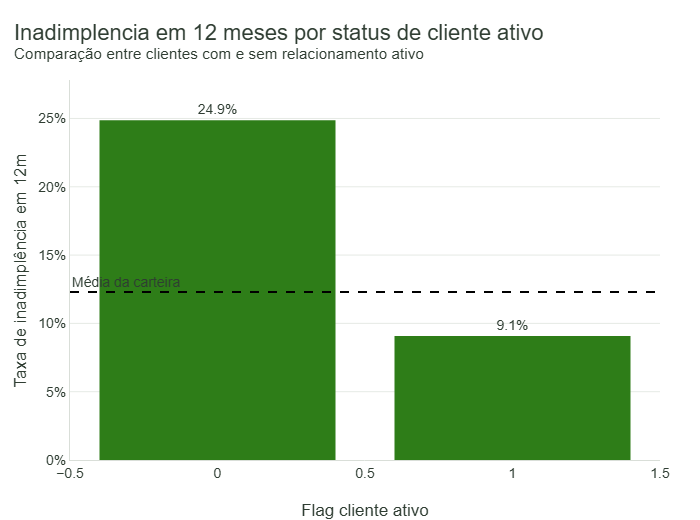

In [67]:
# Aqui eu vou compara clientes ativos e inativos contra a média da carteira.

fig = px.bar(
    risco_cliente_ativo,
    x="flag_cliente_ativo",
    y="taxa_inadimplencia_pct",
    text="taxa_inadimplencia_pct",
)

fig.add_hline(
    y=taxa_media_inad * 100,
    line_dash="dash",
    annotation_text="Média da carteira",
    annotation_position="top left",
)

fig = aplicar_layout(
    fig,
    titulo="Inadimplencia em 12 meses por status de cliente ativo",
    subtitulo="Comparação entre clientes com e sem relacionamento ativo",
    mostrar_legenda=False,
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
)

fig.update_xaxes(title="Flag cliente ativo")
fig.update_yaxes(title="Taxa de inadimplência em 12m", ticksuffix="%")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "03_risco_por_cliente_ativo.html",
)

## 14. Agência

A agência pode capturar diferenças locais, perfil da carteira, atuação comercial ou concentração regional.

Para evitar conclusões frágeis, eu vou usar só agências com volume mínimo de operações. A ideia aqui não é criar uma regra de recusa por agência, mas entender se existe heterogeneidade operacional relevante.

In [68]:
# eu analiso agência com corte mínimo de volume para evitar conclusões instáveis.
# a agência pode capturar diferenças regionais, operacionais ou de perfil da carteira.

risco_agencia = resumo_risco_por_categoria(
    base,
    coluna="cod_agencia",
    min_operacoes=100,
)

# eu converto o código da agência para texto apenas para melhorar exibição em gráfico.
risco_agencia["cod_agencia"] = risco_agencia["cod_agencia"].astype(str)

display(risco_agencia.head(20))

risco_agencia.to_csv(
    TABLES_DIR / "eda_risco_por_agencia.csv",
    index=False,
    encoding="utf-8-sig",
)

,cod_agencia,qtd_operacoes,taxa_inadimplencia,valor_medio,renda_media,comprometimento_medio,taxa_inadimplencia_pct,dif_vs_media_pp
97,98,398,0.1985,"12,681.1707","3,632.7505",0.4951,19.8492,7.5423
92,93,379,0.1873,"13,461.9463","3,628.1523",0.4883,18.7335,6.4265
35,36,152,0.1711,"12,462.8999","3,587.6309",0.4862,17.1053,4.7983
25,26,113,0.1681,"13,308.5827","3,350.0493",0.5227,16.8142,4.5072
30,31,129,0.1628,"10,258.2380","3,197.9471",0.4628,16.2791,3.9721
96,97,374,0.1578,"13,681.3499","3,875.9210",0.5065,15.7754,3.4684
67,68,249,0.1566,"13,387.5390","3,799.1659",0.5034,15.6627,3.3557
27,28,121,0.1488,"13,217.5604","3,543.4368",0.5095,14.8760,2.5690
40,41,135,0.1481,"12,519.0146","3,503.2185",0.4988,14.8148,2.5078
56,57,238,0.1471,"12,624.8508","3,555.8155",0.4915,14.7059,2.3989


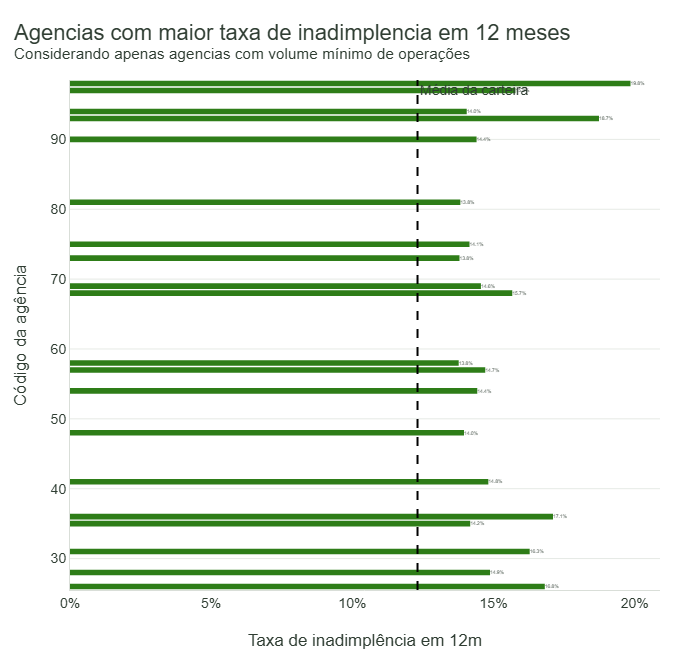

In [69]:
# aqui eu mostro as 20 agências com maior taxa de inadimplência.
# Essa análise é útil para monitoramento, mas não deve virar regra direta de recusa.

top_agencias_risco = risco_agencia.head(20).copy()

fig = px.bar(
    top_agencias_risco.sort_values("taxa_inadimplencia_pct"),
    x="taxa_inadimplencia_pct",
    y="cod_agencia",
    orientation="h",
    text="taxa_inadimplencia_pct",
)

fig.add_vline(
    x=taxa_media_inad * 100,
    line_dash="dash",
    annotation_text="Média da carteira",
    annotation_position="top right",
)

fig = aplicar_layout(
    fig,
    titulo="Agencias com maior taxa de inadimplencia em 12 meses",
    subtitulo="Considerando apenas agencias com volume mínimo de operações",
    mostrar_legenda=False,
    altura=650,
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
)

fig.update_xaxes(title="Taxa de inadimplência em 12m", ticksuffix="%")
fig.update_yaxes(title="Código da agência")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "03_top_agencias_risco.html",
)

## 15. Correlação entre variáveis numéricas

A matriz de correlação ajuda a identificar relações fortes entre variáveis.

Essa análise é útil antes da modelagem, principalmente para regressão logística, porque variáveis muito correlacionadas podem deixar os coeficientes instáveis.

In [70]:
# aqui eu seleciono as principais variáveis numéricas para verificar correlações.
# essa leitura ajuda a antecipar multicolinearidade, principalmente na regressão logística.

cols_numericas = [
    "valor_emprestado",
    "valor_parcela",
    "valor_taxa",
    "valor_prazo",
    "valor_renda",
    "valor_restritivos",
    "idade_concessao",
    "tempo_conta_anos",
    "comprometimento_renda",
    "restritivos_sobre_renda",
    target_col,
]

corr = base[cols_numericas].corr(numeric_only=True)

display(corr)

corr.to_csv(
    TABLES_DIR / "eda_correlacao_variaveis_numericas.csv",
    encoding="utf-8-sig",
)

,valor_emprestado,valor_parcela,valor_taxa,valor_prazo,valor_renda,valor_restritivos,idade_concessao,tempo_conta_anos,comprometimento_renda,restritivos_sobre_renda,target_inadimplente_12m
valor_emprestado,1.0000,0.8785,-0.0267,0.3594,0.6699,0.0035,0.0012,0.0031,0.4812,-0.1587,0.0481
valor_parcela,0.8785,1.0000,-0.0028,-0.0007,0.7668,0.0075,0.0049,0.0020,0.5459,-0.1808,0.0504
valor_taxa,-0.0267,-0.0028,1.0000,0.0081,0.0036,0.0086,-0.0121,-0.0158,-0.0096,0.0061,-0.0132
valor_prazo,0.3594,-0.0007,0.0081,1.0000,-0.0061,-0.0014,-0.0031,0.0023,0.0013,0.0025,0.0002
valor_renda,0.6699,0.7668,0.0036,-0.0061,1.0000,0.0133,0.0002,0.0064,0.0089,-0.2340,-0.0263
valor_restritivos,0.0035,0.0075,0.0086,-0.0014,0.0133,1.0000,0.0140,0.0025,-0.0065,0.8378,0.1566
idade_concessao,0.0012,0.0049,-0.0121,-0.0031,0.0002,0.0140,1.0000,0.0071,0.0083,0.0142,-0.0960
tempo_conta_anos,0.0031,0.0020,-0.0158,0.0023,0.0064,0.0025,0.0071,1.0000,-0.0045,0.0012,-0.1096
comprometimento_renda,0.4812,0.5459,-0.0096,0.0013,0.0089,-0.0065,0.0083,-0.0045,1.0000,-0.0090,0.1338
restritivos_sobre_renda,-0.1587,-0.1808,0.0061,0.0025,-0.2340,0.8378,0.0142,0.0012,-0.0090,1.0000,0.1420


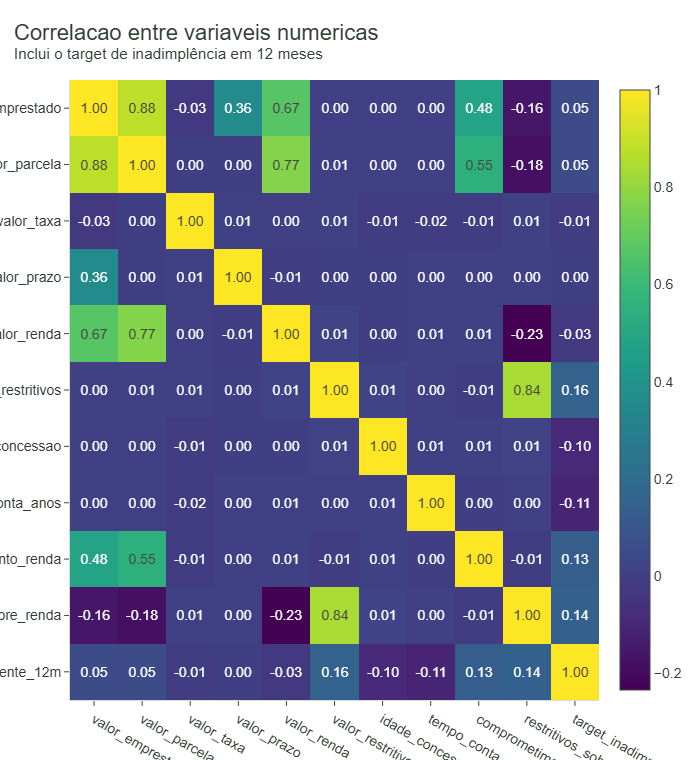

In [71]:
# Mapa de calor para facilitar a leitura visual das relações entre variáveis.
# Correlações muito altas entre explicativas podem exigir seleção de variáveis na modelagem.

fig = px.imshow(
    corr,
    text_auto=".2f",
    aspect="auto",
)

fig = aplicar_layout(
    fig,
    titulo="Correlacao entre variaveis numericas",
    subtitulo="Inclui o target de inadimplência em 12 meses",
    mostrar_legenda=True,
    altura=760,
)

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "03_correlacao_variaveis_numericas.html",
)

## 16. Consolidação dos principais sinais de política

Nessa seção consolido os sinais exploratórios mais relevantes.

A ideia é começar a traduzir a EDA em critérios que serão usados depois na política de concessão:

- variáveis com forte separação de risco;
- variáveis úteis para limitar valor;
- variáveis que podem entrar no modelo, mas exigem cautela na regra de negócio.

In [72]:
# Consolido a interpretação inicial das variáveis.
# Essa tabela conecta os achados da EDA com a política que será proposta no final do case.

sinais_politica = pd.DataFrame({
    "variavel": [
        "comprometimento_renda",
        "valor_restritivos",
        "restritivos_sobre_renda",
        "valor_emprestado",
        "valor_parcela",
        "valor_prazo",
        "valor_taxa",
        "valor_renda",
        "tempo_conta_anos",
        "flag_cliente_ativo",
        "cat_escolaridade",
        "cod_agencia",
    ],
    "uso_politica": [
        "Limite de parcela e valor máximo",
        "Restrição ou redutor de limite",
        "Restrição ou redutor de limite",
        "Controle de exposição",
        "Capacidade de pagamento",
        "Condição da operação",
        "Condição da operação e proxy de risco",
        "Capacidade de pagamento",
        "Ajuste de risco",
        "Ajuste de risco",
        "Variável cadastral para modelo",
        "Monitoramento operacional",
    ],
    "comentario": [
        "Ajuda a evitar parcelas incompatíveis com renda.",
        "Sinaliza pressão financeira antes da concessão.",
        "Compara dívidas restritivas com capacidade de renda.",
        "Ajuda a definir teto de exposição por cliente.",
        "Complementa a leitura de capacidade de pagamento.",
        "Afeta parcela e duração do risco.",
        "Pode refletir risco já precificado.",
        "Sozinha é insuficiente para definir aprovação.",
        "Pode indicar relacionamento mais maduro.",
        "Pode diferenciar vínculo ativo com a instituição.",
        "Deve ser usada com cautela na decisão.",
        "Útil para monitoramento, não como regra direta.",
    ],
})

display(sinais_politica)

sinais_politica.to_csv(
    TABLES_DIR / "eda_sinais_para_politica.csv",
    index=False,
    encoding="utf-8-sig",
)

,variavel,uso_politica,comentario
0,comprometimento_renda,Limite de parcela e valor máximo,Ajuda a evitar parcelas incompatíveis com renda.
1,valor_restritivos,Restrição ou redutor de limite,Sinaliza pressão financeira antes da concessão.
2,restritivos_sobre_renda,Restrição ou redutor de limite,Compara dívidas restritivas com capacidade de ...
3,valor_emprestado,Controle de exposição,Ajuda a definir teto de exposição por cliente.
4,valor_parcela,Capacidade de pagamento,Complementa a leitura de capacidade de pagamento.
5,valor_prazo,Condição da operação,Afeta parcela e duração do risco.
6,valor_taxa,Condição da operação e proxy de risco,Pode refletir risco já precificado.
7,valor_renda,Capacidade de pagamento,Sozinha é insuficiente para definir aprovação.
8,tempo_conta_anos,Ajuste de risco,Pode indicar relacionamento mais maduro.
9,flag_cliente_ativo,Ajuste de risco,Pode diferenciar vínculo ativo com a instituição.


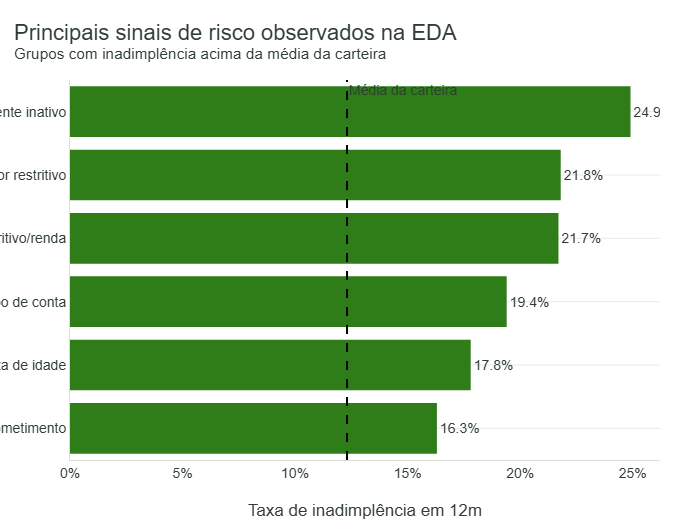

In [73]:
# Consolido os principais sinais da EDA em um gráfico simples.
# A ideia é mostrar rapidamente quais grupos ficaram mais acima da média da carteira.

resumo_sinais_eda = pd.DataFrame({
    "sinal": [
        "Cliente inativo",
        "Pouco tempo de conta",
        "Maior restritivo/renda",
        "Maior valor restritivo",
        "Menor faixa de idade",
        "Maior comprometimento",
    ],
    "taxa_inadimplencia_pct": [
        24.9,
        19.4,
        21.7,
        21.8,
        17.8,
        16.3,
    ],
})

fig = px.bar(
    resumo_sinais_eda.sort_values("taxa_inadimplencia_pct"),
    x="taxa_inadimplencia_pct",
    y="sinal",
    orientation="h",
    text="taxa_inadimplencia_pct",
)

fig.add_vline(
    x=taxa_media_inad * 100,
    line_dash="dash",
    annotation_text="Média da carteira",
    annotation_position="top right",
)

fig = aplicar_layout(
    fig,
    titulo="Principais sinais de risco observados na EDA",
    subtitulo="Grupos com inadimplência acima da média da carteira",
    mostrar_legenda=False,
    altura=520,
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
)

fig.update_xaxes(title="Taxa de inadimplência em 12m", ticksuffix="%")
fig.update_yaxes(title="")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "03_resumo_sinais_risco_eda.html",
)

## 17. Conclusões da análise exploratória

A EDA mostra que a taxa média de inadimplência em 12 meses é de **12,3%**. A renda, isoladamente, não separa tão bem bons e maus pagadores, por isso não deve ser usada sozinha como regra de aprovação.

Os sinais mais fortes de risco aparecem em variáveis ligadas a **capacidade de pagamento**, **restritivos financeiros** e **relacionamento com a instituição**. Clientes com maior comprometimento de renda, maior peso de restritivos, pouco tempo de conta ou relacionamento inativo apresentam inadimplência bem acima da média da carteira.

O resultado mais importante para a política é que o valor máximo concedido deve ser limitado por uma combinação de:

* probabilidade de inadimplência estimada pelo modelo;
* parcela máxima suportável pela renda;
* nível de restritivos;
* tempo de relacionamento e status de cliente ativo.

Assim, a política final não deve ser apenas “aprovar ou recusar”. Ela deve combinar **score de risco + capacidade de pagamento + redutores de limite** para definir quanto emprestar com menor exposição ao risco.

A próxima etapa será treinar modelos de PD em 12 meses e transformar esses sinais em uma regra objetiva de concessão e limite máximo.
